# Modelado — Predicción de reingreso hospitalario 

En este notebook se entrenan y comparan distintos modelos de clasificación para predecir el reingreso hospitalario dentro de los 30 días posteriores al alta.

El objetivo de esta fase es identificar qué algoritmo ofrece mejor capacidad discriminativa sobre el dataset preprocesado, sentando la base para el análisis en profundidad del notebook de evaluación.

**Modelos evaluados:**
- Regresión Logística (baseline lineal interpretable)
- Random Forest (conjunto de árboles, captura relaciones no lineales)
- XGBoost (gradient boosting, robusto con datos tabulares)
- LightGBM (gradient boosting optimizado en velocidad y memoria)

**Métricas principales:** ROC-AUC y Recall, dado que en contexto clínico interesa detectar el máximo número de pacientes en riesgo real.

## 1. Imports y configuración

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

from src.models.train import (
    load_data, split_data, get_models,
    run_all_models, cross_validate_model, tune_model, get_metrics
)
from src.evaluation.evaluate import (
    plot_confusion_matrix, get_classification_report
)

## 2. Carga del dataset

In [2]:
X, y, groups = load_data()

print(f"Dataset: {X.shape[0]:,} registros — {X.shape[1]} variables predictoras")
print(f"\nDistribución de la variable objetivo:")
print(y.value_counts())
print(f"\nProporción positivos (readmisión): {y.mean():.1%}")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342. Split: por paciente (GroupShuffleSplit)
Dataset: 315,982 registros — 54 variables predictoras

Distribución de la variable objetivo:
readmission_30_days
0    208032
1    107950
Name: count, dtype: int64

Proporción positivos (readmisión): 34.2%


### Nota sobre el desbalanceo de clases y estrategia de balanceo

La variable objetivo presenta una distribución de 65.8% negativo / 34.2% positivo. Este desbalanceo es moderado pero, con el umbral por defecto de 0.5, los modelos tienden a priorizar la clase mayoritaria y producen un recall muy bajo sobre la clase de interés clínico (readmisión).

**Estrategia adoptada:** todos los modelos se entrenan con `class_weight='balanced'` (o `scale_pos_weight` en XGBoost), lo que ajusta los pesos de las clases inversamente proporcional a su frecuencia. Esto aumenta el recall a costa de algo de precisión, que es el trade-off deseable en un contexto de screening clínico donde el coste de los falsos negativos (pacientes en riesgo no detectados) es mayor que el de los falsos positivos.

## 3. División en entrenamiento, validación y test

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, groups)

print(f"Train: {X_train.shape[0]:,} registros ({y_train.mean():.1%} positivos)")
print(f"Val:   {X_val.shape[0]:,} registros ({y_val.mean():.1%} positivos)")
print(f"Test:  {X_test.shape[0]:,} registros ({y_test.mean():.1%} positivos)")

Train: 189,245 registros (34.2% positivos)
Val:   62,611 registros (33.8% positivos)
Test:  64,126 registros (34.6% positivos)


## 4. Entrenamiento y comparación de modelos

Los modelos se ordenan por ROC-AUC con Average Precision (PR-AUC) como criterio de desempate. 
ROC-AUC resume cómo de bien separa el modelo los reingresos de los que no reingresan; 
Average Precision complementa esa medida centrándose en la clase positiva, lo que es más útil cuando hay desbalanceo. 
Ambas métricas se evalúan sobre el **conjunto de validación** (20% de los datos), reservando el test set exclusivamente para la evaluación final del modelo optimizado.

In [4]:
results_df, trained_models = run_all_models(X_train, X_val, y_train, y_val)
results_df

Training models...
  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision,Train time (s)
Model,,,,,,,
LightGBM,0.6136,0.4451,0.5849,0.5055,0.6512,0.4822,1.2
XGBoost,0.6142,0.4455,0.5819,0.5046,0.6500,0.4820,3.8
Logistic Regression,0.6133,0.4412,0.5443,0.4873,0.6327,0.4537,1.3
Random Forest,0.6493,0.4578,0.2093,0.2873,0.6094,0.4267,21.8


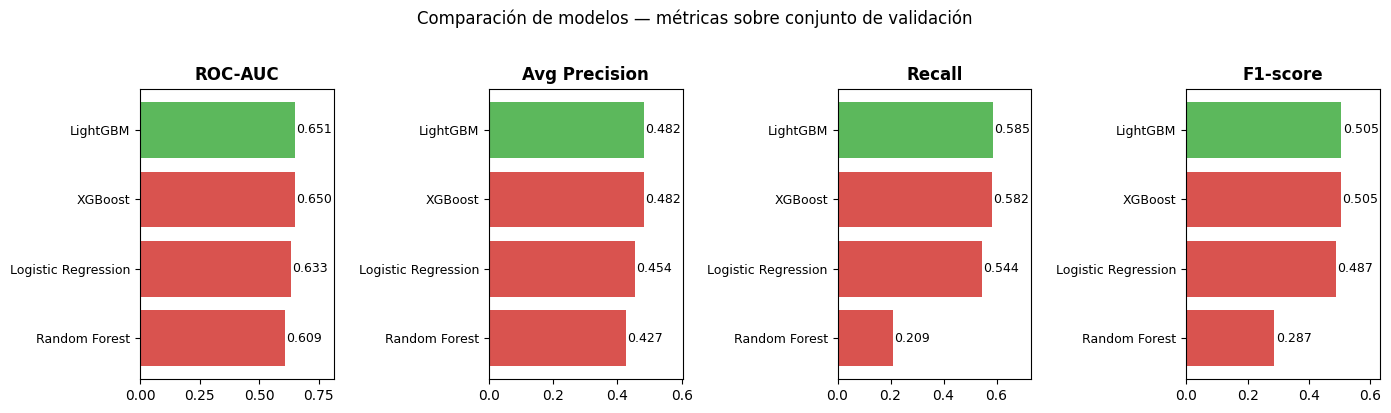

In [5]:
# Gráfico comparativo de modelos en las métricas clave
metrics_to_plot = ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].sort_values()
    colors = ["#d9534f" if m != results_df[metric].idxmax() else "#5cb85c" for m in values.index]
    bars = ax.barh(values.index, values.values, color=colors)
    ax.set_xlim(0, max(values.values) * 1.25)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("")
    for bar, val in zip(bars, values.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Comparación de modelos — métricas sobre conjunto de validación", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../results/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Justificación de la selección del modelo

La elección del modelo final combina tres criterios: rendimiento (ROC-AUC), relevancia clínica (Recall) e interpretabilidad (soporte SHAP).

**Regresión Logística** queda como baseline: su AUC de 0.633 es el más bajo y su supuesto de linealidad no captura bien las interacciones entre variables clínicas.

**Random Forest** se descarta por un Recall de 0.21 (detecta solo 1 de cada 5 reingresos reales), lo que es clínicamente inaceptable en un sistema de screening.

**XGBoost y LightGBM** son prácticamente equivalentes en rendimiento sobre validación (AUC 0.6512 vs 0.6500). Se elige **LightGBM** por obtener el mayor ROC-AUC y Average Precision sobre el conjunto de validación (0.4822 vs 0.4820), ambas métricas clave en el contexto clínico de este proyecto. Tras la optimización de hiperparámetros, el modelo final alcanza un AUC de 0.6568 sobre el test set.

El análisis en profundidad del modelo seleccionado se realiza en `04_evaluation.ipynb`.

## 4.1 Curvas ROC — comparación de los cuatro modelos base


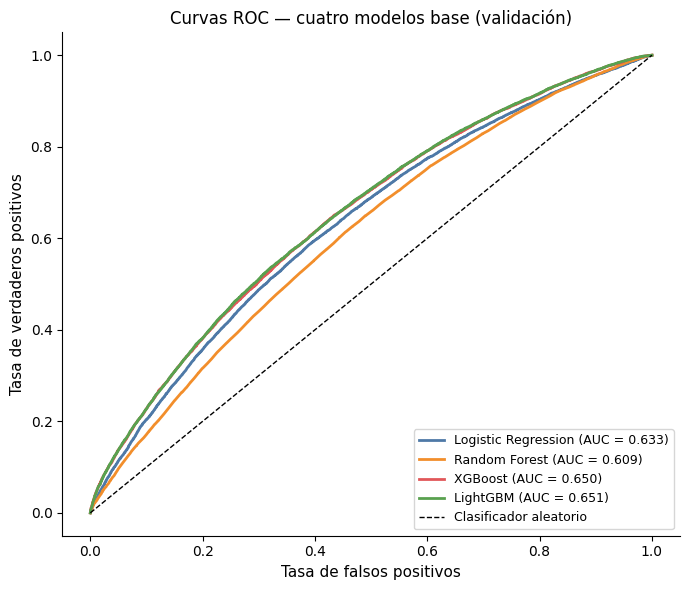

Guardado: results/roc_4models.png


In [6]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Solo los 4 modelos base, evaluados sobre validación
base_models = {k: v for k, v in trained_models.items() if "tuned" not in k.lower()}

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#4e79a7", "#f28e2b", "#e15759", "#59a14f"]

for (name, model), color in zip(base_models.items(), colors):
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos", fontsize=11)
ax.set_ylabel("Tasa de verdaderos positivos", fontsize=11)
ax.set_title("Curvas ROC — cuatro modelos base (validación)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/roc_4models.png", dpi=180, bbox_inches="tight")
plt.show()
print("Guardado: results/roc_4models.png")

## 5. Validación cruzada del mejor modelo

Se aplica validación cruzada estratificada de 5 folds **solo sobre el conjunto de entrenamiento** para estimar la estabilidad del modelo sin tocar el test set.

El AUC medio del CV es ligeramente inferior al del modelo final porque cada fold entrena con el 80% del train (~202k filas) frente a las ~253k del modelo completo. Esto es normal y no indica ningún problema (el CV sirve para detectar varianza entre folds, no para medir el rendimiento definitivo).

In [7]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"Mejor modelo: {best_model_name}")
print(f"ROC-AUC (val): {results_df.loc[best_model_name, 'ROC-AUC']}")

# CV sobre X_train/y_train únicamente — ni val ni test participan
groups_train = groups.loc[X_train.index]
cv_results = cross_validate_model(best_model, X_train, y_train, cv=5, groups=groups_train)
print(f"ROC-AUC (CV 5-fold sobre train): {cv_results['cv_roc_auc_mean']} ± {cv_results['cv_roc_auc_std']}")

Mejor modelo: LightGBM
ROC-AUC (val): 0.6512
ROC-AUC (CV 5-fold sobre train): 0.6526 ± 0.0028


## 6. Optimización de hiperparámetros

Los modelos de la sección anterior se entrenaron con hiperparámetros por defecto. En esta sección se aplica `RandomizedSearchCV` sobre el mejor modelo (LightGBM) para explorar el espacio de hiperparámetros de forma sistemática.

**Metodología:**
- Se exploran 20 combinaciones aleatorias del espacio de búsqueda definido en `src/models/train.tune_model`
- La validación cruzada interna es de 3 folds estratificados, exclusivamente sobre `X_train` (sin contacto con `X_val` ni `X_test`)
- El scoring es ROC-AUC, consistente con la métrica principal del proyecto
- El modelo resultante se reentrena con los mejores hiperparámetros sobre todo `X_train` antes de evaluarse en test

In [8]:
groups_train = groups.loc[X_train.index]
best_model_tuned, best_params, tune_cv = tune_model(
    best_model_name, X_train, y_train, n_iter=20, cv=3, groups=groups_train
)

# Reevaluamos el baseline sobre test para que la comparación sea justa
# (results_df tiene métricas de validación; aquí ambos modelos se evalúan en test)
y_pred_base  = trained_models[best_model_name].predict(X_test)
y_prob_base  = trained_models[best_model_name].predict_proba(X_test)[:, 1]
metrics_base_test = get_metrics(y_test, y_pred_base, y_prob_base)

y_pred_tuned = best_model_tuned.predict(X_test)
y_prob_tuned = best_model_tuned.predict_proba(X_test)[:, 1]
metrics_tuned = get_metrics(y_test, y_pred_tuned, y_prob_tuned)

print("\n--- Comparación baseline vs optimizado (ambos sobre test set) ---")
print(f"{'Métrica':<18} {'Baseline':>10} {'Optimizado':>10} {'Mejora':>10}")
print("-" * 50)
for metric in ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]:
    baseline = round(metrics_base_test[metric], 4)
    tuned    = round(metrics_tuned[metric], 4)
    diff     = round(tuned - baseline, 4)
    sign     = "+" if diff >= 0 else ""
    print(f"{metric:<18} {baseline:>10.4f} {tuned:>10.4f} {sign+str(diff):>10}")

print(f"\nROC-AUC (CV interna optimización, 3 folds): {tune_cv['cv_roc_auc_mean']} ± {tune_cv['cv_roc_auc_std']}")

# El modelo optimizado pasa a ser el modelo principal del resto del análisis.
best_model = best_model_tuned
best_model_name = f"{best_model_name} (optimizado)"
trained_models[best_model_name] = best_model

Optimizando hiperparámetros de LightGBM (20 iteraciones, CV=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 600, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.8, 'bagging_freq': 5}
ROC-AUC medio (CV interna): 0.6550

--- Comparación baseline vs optimizado (ambos sobre test set) ---
Métrica              Baseline Optimizado     Mejora
--------------------------------------------------
ROC-AUC                0.6547     0.6568    +0.0021
Avg Precision          0.5049     0.5085    +0.0036
Recall                 0.5940     0.5955    +0.0015
F1-score               0.5152     0.5157    +0.0005

ROC-AUC (CV interna optimización, 3 folds): 0.655 ± 0.004


## 7. Curvas ROC — comparación de modelos

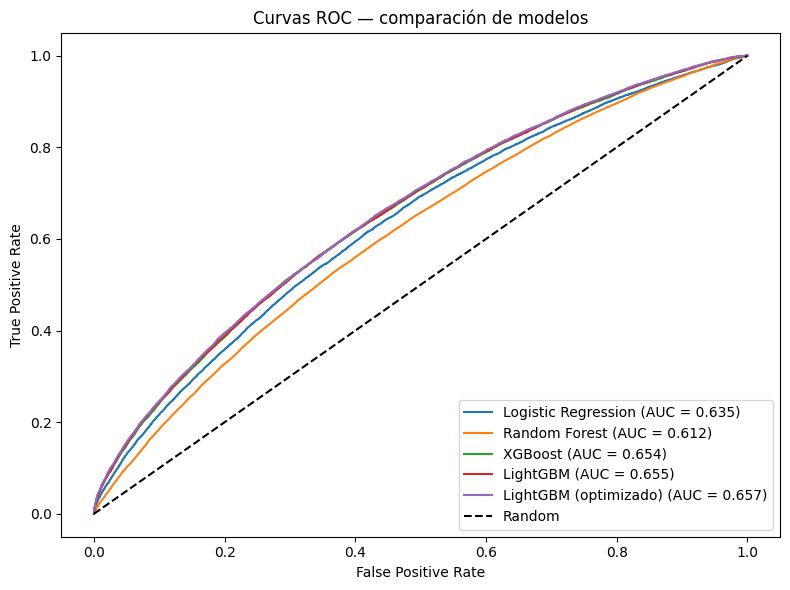

In [9]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — comparación de modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/roc_curves_comparison.png", dpi=150)
plt.show()

## 8. Matriz de confusión del mejor modelo

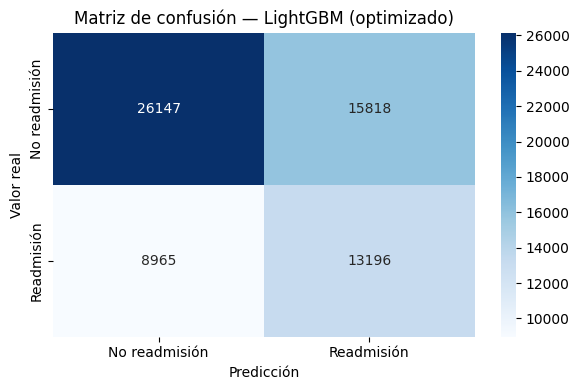


Classification Report:
               precision  recall  f1-score    support
No readmisión      0.745   0.623     0.678  41965.000
Readmisión         0.455   0.595     0.516  22161.000
accuracy           0.614   0.614     0.614      0.614
macro avg          0.600   0.609     0.597  64126.000
weighted avg       0.645   0.614     0.622  64126.000


In [10]:
plot_confusion_matrix(
    best_model, X_test, y_test, best_model_name,
    save_path="../results/confusion_matrix_best.png"
)

print("\nClassification Report:")
print(get_classification_report(best_model, X_test, y_test).to_string())

## 9. Guardado de resultados

In [11]:
import glob as _glob

# Añadir métricas del modelo optimizado a la tabla comparativa y guardar
tuned_row = pd.DataFrame([{**metrics_tuned, "Train time (s)": np.nan}], index=[best_model_name])
tuned_row = tuned_row.round(4)
results_full = pd.concat([results_df, tuned_row])
results_full.to_csv("../results/model_comparison.csv")

# Eliminar modelos anteriores para evitar que notebook 04 cargue un pkl equivocado
for old_path in _glob.glob("../models/*.pkl"):
    os.remove(old_path)

# Guardar el modelo optimizado
model_path = f"../models/{best_model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.pkl"
joblib.dump(best_model, model_path)

print(f"Métricas guardadas en results/model_comparison.csv")
print(f"Mejor modelo guardado en {model_path}")
print(f"\nTabla final:")
results_full[["Accuracy", "Recall", "F1-score", "ROC-AUC", "Avg Precision"]]

Métricas guardadas en results/model_comparison.csv
Mejor modelo guardado en ../models/lightgbm_optimizado.pkl

Tabla final:


,Accuracy,Recall,F1-score,ROC-AUC,Avg Precision
LightGBM,0.6136,0.5849,0.5055,0.6512,0.4822
XGBoost,0.6142,0.5819,0.5046,0.6500,0.4820
Logistic Regression,0.6133,0.5443,0.4873,0.6327,0.4537
Random Forest,0.6493,0.2093,0.2873,0.6094,0.4267
LightGBM (optimizado),0.6135,0.5955,0.5157,0.6568,0.5085


## 10. Conclusiones

**XGBoost y LightGBM** obtienen resultados prácticamente equivalentes en la comparación base (diferencia de 0.0012 ROC-AUC). Esto es esperable: ambos son implementaciones de gradient boosting sobre árboles y convergen a soluciones similares con datos de este volumen. El modelo final se selecciona tras la optimización de hiperparámetros sobre el conjunto de validación; la evaluación sobre el test set confirma su capacidad discriminativa.

**Sobre la estrategia de división de datos:** el proyecto utiliza una partición por paciente (`subject_id`) mediante `GroupShuffleSplit`, garantizando que ningún paciente aparece simultáneamente en train, validación y test. Se comparó esta estrategia con la división aleatoria por admisión (versión anterior): las métricas finales difieren en menos de 0.002 AUC. Esto indica que el modelo aprendía patrones clínicos reales y no se beneficiaba de "recordar" admisiones previas del mismo paciente. La versión actual es metodológicamente más rigurosa aunque el impacto práctico sea mínimo.

Un AUC en el rango 0.65–0.67 es coherente con la literatura para reingreso a 30 días con datos administrativos (LACE+: 0.63–0.72). El techo está limitado por los propios datos: sin variables clínicas como signos vitales o analíticas, la capacidad predictiva tiene un límite estructural.

El análisis en profundidad se realiza en `04_evaluation.ipynb`.